# Step 8: Tune Physics Weight (λ)

## Why

Total loss = **data MSE + λ × PDE residual**.

With `λ = 0.01` the physics term was tiny in training.
This notebook sweeps λ and writes `physics_best.pkl` so `02_pinn_model.ipynb` picks it up.

## What “good” looks like

- Too small λ → physics ignored (old behaviour)
- Too large λ → data fit collapses, val MAE gets worse
- Best λ → lowest **val_loss** (data + physics) without blowing up MAE

In [1]:
import os
import pickle
import pandas as pd
import matplotlib.pyplot as plt

from tune_physics import tune

print("X_train exists:", os.path.exists("X_train.npy"))
print("advection.pkl exists:", os.path.exists("advection.pkl"))

X_train exists: True
advection.pkl exists: True


## Run the sweep

Short runs (25 epochs) per weight — enough to rank λ, not final training.

In [2]:
results = tune(weights=[0.0, 0.01, 0.05, 0.1, 0.3], epochs=25)
results


=== physics_weight=0.0 ===
  best_val_loss=0.016732  val_mae=0.094536  val_physics=0.048548

=== physics_weight=0.01 ===
  best_val_loss=0.017570  val_mae=0.095296  val_physics=0.025086

=== physics_weight=0.05 ===
  best_val_loss=0.017278  val_mae=0.095690  val_physics=0.164159

=== physics_weight=0.1 ===
  best_val_loss=0.022733  val_mae=0.096320  val_physics=0.066644

=== physics_weight=0.3 ===
  best_val_loss=0.023157  val_mae=0.097506  val_physics=0.143774

PHYSICS TUNE RESULTS
 physics_weight  best_val_loss  final_val_data_loss  final_val_physics_loss  best_val_mae  epochs_run
           0.00       0.016732             0.016796                0.048548      0.094536          25
           0.01       0.017570             0.018204                0.025086      0.095296          20
           0.05       0.017278             0.017094                0.164159      0.095690           9
           0.10       0.022733             0.017323                0.066644      0.096320           9
 

,physics_weight,best_val_loss,final_val_data_loss,final_val_physics_loss,best_val_mae,epochs_run
0,0.00,0.016732,0.016796,0.048548,0.094536,25
1,0.01,0.017570,0.018204,0.025086,0.095296,20
2,0.05,0.017278,0.017094,0.164159,0.095690,9
3,0.10,0.022733,0.017323,0.066644,0.096320,9
4,0.30,0.023157,0.018038,0.143774,0.097506,9


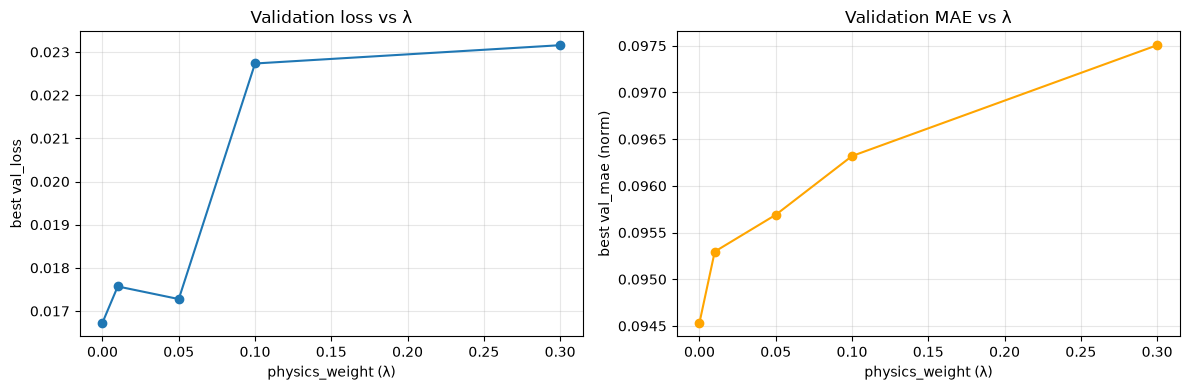

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(results["physics_weight"], results["best_val_loss"], "o-")
axes[0].set_xlabel("physics_weight (λ)")
axes[0].set_ylabel("best val_loss")
axes[0].set_title("Validation loss vs λ")
axes[0].grid(True, alpha=0.3)

axes[1].plot(results["physics_weight"], results["best_val_mae"], "o-", color="orange")
axes[1].set_xlabel("physics_weight (λ)")
axes[1].set_ylabel("best val_mae (norm)")
axes[1].set_title("Validation MAE vs λ")
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [4]:
with open("physics_best.pkl", "rb") as f:
    best = pickle.load(f)
print("Use this in 02_pinn_model.ipynb:")
best

Use this in 02_pinn_model.ipynb:


{'physics_weight': 0.0,
 'val_loss': 0.016731705516576767,
 'val_mae': 0.09453556686639786,
 'u_adv': 0.025866422465489782,
 'v_adv': 0.0036664258136414438,
 'alpha': 0.01}

## Next

1. Re-run **`02_pinn_model.ipynb`** (loads `physics_best.pkl` automatically)
2. Re-run **`07_improve_forecasts.ipynb`** Parts B–D if you want fresh recal + forecast head
3. Open **`06_evaluation.ipynb`** for the final report